In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ad_df = pd.read_csv("ad_spend_data.csv")
web_df = pd.read_csv("web_analytics_log.csv")
crm_df = pd.read_csv("crm_conversion_data.csv")

In [45]:
print("Ad Spend:", ad_df.shape)
print("Web Analytics:", web_df.shape)
print("CRM:", crm_df.shape)

Ad Spend: (1350, 7)
Web Analytics: (6034, 10)
CRM: (600, 7)


In [46]:
ad_df.info()
web_df.info()
crm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1350 non-null   str    
 1   channel           1350 non-null   str    
 2   campaign          1350 non-null   str    
 3   amount_spent_usd  1350 non-null   float64
 4   clicks            1350 non-null   int64  
 5   impressions       1350 non-null   int64  
 6   cpc               1350 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 116.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 6034 entries, 0 to 6033
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   session_id            6034 non-null   str  
 1   user_id               6034 non-null   str  
 2   timestamp             6034 non-null   str  
 3   channel               6034 non-null   str  
 4   utm_source            5434 

In [47]:
print(ad_df.isnull().sum())

print(web_df.isnull().sum())

print(crm_df.isnull().sum())

date                0
channel             0
campaign            0
amount_spent_usd    0
clicks              0
impressions         0
cpc                 0
dtype: int64
session_id                0
user_id                   0
timestamp                 0
channel                   0
utm_source              600
utm_medium                0
utm_campaign            299
page_visited              0
session_duration_sec      0
device                    0
dtype: int64
customer_id             0
conversion_date         0
revenue_usd             0
last_touch_channel      0
last_touch_campaign    33
product_purchased       0
country                 0
dtype: int64


In [48]:
channel_spend = (
    ad_df.groupby("channel")["amount_spent_usd"]
    .sum()
    .sort_values(ascending=False)
)

print(channel_spend)

channel
Google_Search    483302.68
Meta_Facebook    304221.15
LinkedIn         252163.24
TikTok           150570.08
Email             45909.35
Organic               0.00
Name: amount_spent_usd, dtype: float64


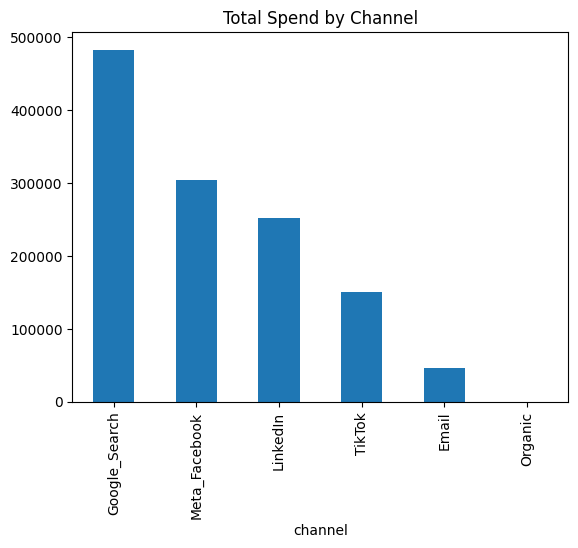

In [49]:
channel_spend.plot(kind="bar")

plt.title("Total Spend by Channel")

plt.show()

In [50]:
crm_df["revenue_usd"].sum()

np.float64(157479.27000000002)

In [51]:
crm_df["revenue_usd"].mean()

np.float64(262.46545000000003)

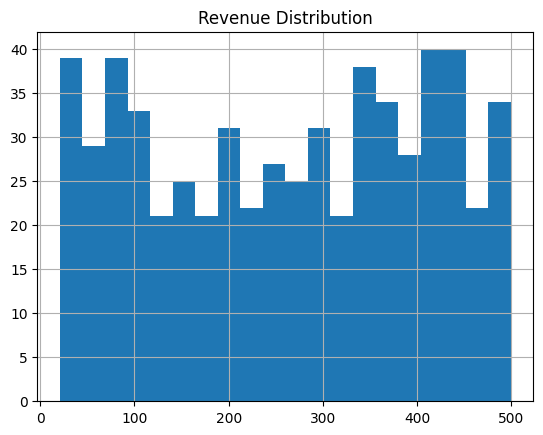

In [52]:
crm_df["revenue_usd"].hist(bins=20)

plt.title("Revenue Distribution")

plt.show()

In [53]:
web_df["channel"].value_counts()

channel
Google_Search    1752
Meta_Facebook    1518
TikTok            922
Email             622
Organic           616
LinkedIn          604
Name: count, dtype: int64

In [54]:
web_df.groupby("user_id").size().describe()

count    2000.000000
mean        3.017000
std         1.417644
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
dtype: float64

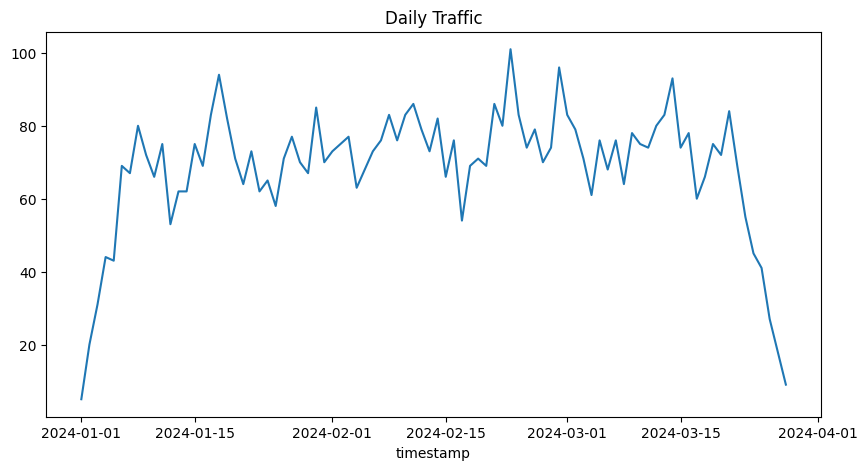

In [55]:
web_df["timestamp"] = pd.to_datetime(
    web_df["timestamp"]
)

daily = (
    web_df
    .groupby(web_df["timestamp"].dt.date)
    .size()
)

daily.plot(figsize=(10,5))
plt.title("Daily Traffic")
plt.show()